<a href="https://colab.research.google.com/github/sttr47/cnn-mnist/blob/main/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [ ]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


In [ ]:
train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.head(x)

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self):
        super(MLPBaseline, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
def train(model, optimizer, criterion, train_loader, val_loader, epochs=5, lr = 0.001):

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        v_loss = val_loss / val_total
        v_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(v_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f}")

    return history

In [ ]:
def evaluate(model, test_loader, criterion):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    final_loss = test_loss / total
    final_acc = (correct / total) * 100
    return final_loss, final_acc

In [ ]:
epochs = 3
lr = 0.001
criterion = nn.CrossEntropyLoss()

print("TRAINING CNN...")
model_cnn = CNNClassifier().to(device)
cnn_optimizer = torch.optim.Adam(model_cnn.parameters(), lr=lr)
cnn_history = train(model_cnn, cnn_optimizer, criterion, train_loader, val_loader, epochs=epochs)

print("TRAINING MLP...")
model_mlp = MLPBaseline().to(device)
mlp_optimizer = torch.optim.Adam(model_mlp.parameters(), lr=lr)
mlp_history = train(model_mlp, mlp_optimizer, criterion, train_loader, val_loader, epochs=epochs)


cnn_test_loss, cnn_test_acc = evaluate(model_cnn, test_loader, criterion)
mlp_test_loss, mlp_test_acc = evaluate(model_mlp, test_loader, criterion)

print(f"TEST RESULT:")
print(f"CNN Test Acc: {cnn_test_acc:.2f}% | Test Loss: {cnn_test_loss:.4f}")
print(f"MLP Test Acc: {mlp_test_acc:.2f}% | Test Loss: {mlp_test_loss:.4f}")

TRAINING CNN...
Epoch 1/3 | Train Loss: 0.1462, Acc: 0.9543 | Val Loss: 0.0647, Acc: 0.9817
Epoch 2/3 | Train Loss: 0.0451, Acc: 0.9857 | Val Loss: 0.0505, Acc: 0.9843
Epoch 3/3 | Train Loss: 0.0303, Acc: 0.9906 | Val Loss: 0.0412, Acc: 0.9887
TRAINING MLP...
Epoch 1/3 | Train Loss: 0.2260, Acc: 0.9315 | Val Loss: 0.1225, Acc: 0.9629
Epoch 2/3 | Train Loss: 0.0929, Acc: 0.9713 | Val Loss: 0.1090, Acc: 0.9675
Epoch 3/3 | Train Loss: 0.0628, Acc: 0.9805 | Val Loss: 0.0889, Acc: 0.9735
TEST RESULT:
CNN Test Acc: 98.93% | Test Loss: 0.0326
MLP Test Acc: 97.65% | Test Loss: 0.0755


In [ ]:
import matplotlib.pyplot as plt

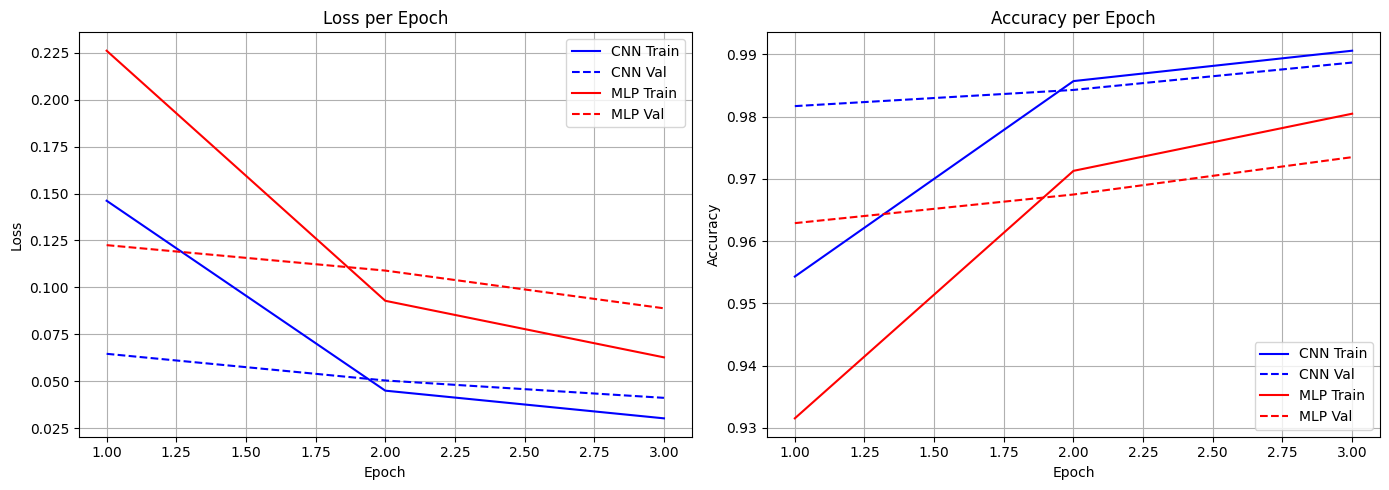

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(range(1, epochs+1), cnn_history['train_loss'], 'b-', label='CNN Train')
axs[0].plot(range(1, epochs+1), cnn_history['val_loss'], 'b--', label='CNN Val')
axs[0].plot(range(1, epochs+1), mlp_history['train_loss'], 'r-', label='MLP Train')
axs[0].plot(range(1, epochs+1), mlp_history['val_loss'], 'r--', label='MLP Val')
axs[0].set_title('Loss per Epoch')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(range(1, epochs+1), cnn_history['train_acc'], 'b-', label='CNN Train')
axs[1].plot(range(1, epochs+1), cnn_history['val_acc'], 'b--', label='CNN Val')
axs[1].plot(range(1, epochs+1), mlp_history['train_acc'], 'r-', label='MLP Train')
axs[1].plot(range(1, epochs+1), mlp_history['val_acc'], 'r--', label='MLP Val')
axs[1].set_title('Accuracy per Epoch')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

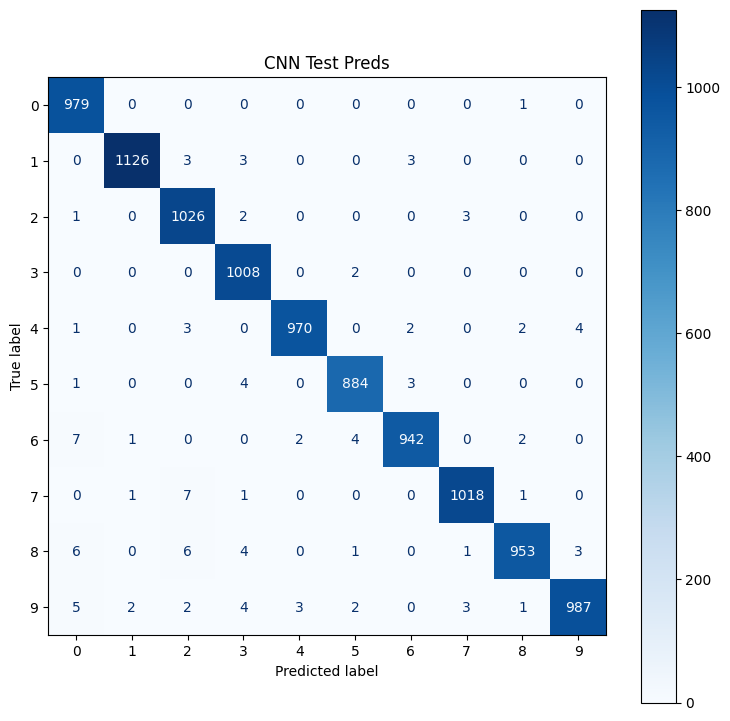

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def analyze_confusion_matrix(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(9, 9))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title("CNN Test Preds")
    plt.show()

analyze_confusion_matrix(model_cnn, test_loader, device)

In [ ]:
torch.save(model_cnn.state_dict(), "cnn_mnist.pth")

In [ ]:
from PIL import Image, ImageOps
from torchvision import transforms

model = CNNClassifier().to(device)
model.load_state_dict(torch.load("cnn_mnist.pth", map_location=device))
model.eval()

image_files = ["digit_0.jpg", "digit_1.jpg", "digit_2.jpg", "digit_3.jpg", "digit_4.jpg", "digit_5.jpg", "digit_6.jpg", "digit_7.jpg", "digit_8.jpg", "digit_9.jpg"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Testing...")
for file_path in image_files:
    img = Image.open(file_path).convert('L')
    img = ImageOps.invert(img)
    img = img.resize((28, 28))
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = torch.argmax(output, dim=1).item()

    print(f"file: {file_path} -> predicted: {pred}")

Testing...
file: digit_0.jpg -> predicted: 0
file: digit_1.jpg -> predicted: 1
file: digit_2.jpg -> predicted: 2
file: digit_3.jpg -> predicted: 3
file: digit_4.jpg -> predicted: 4
file: digit_5.jpg -> predicted: 5
file: digit_6.jpg -> predicted: 6
file: digit_7.jpg -> predicted: 7
file: digit_8.jpg -> predicted: 8
file: digit_9.jpg -> predicted: 3
